# Listen what you won't — Basic Experiment

This notebook goes through this process:

1. Generate a random network with assigned opinions
2. Apply HK model until convergence
3. Apply rewiring to force echo chambers
4. Visualize the network and metrics through each phase.
---

## 0 · Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from network_gen   import make_network, get_opinions
from hk_dynamics   import hk_run_history, opinion_variance, n_clusters, polarization_index
from simulation    import run_simulation, compute_metrics
from visualization import (
    plot_network_opinion,
    plot_network_community,
    plot_snapshots,
    plot_metrics,
    plot_opinion_histogram,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

---
## 1 · Generate the network

We create a network Barabási-Albert with **200 nodos** and **uniform** opinion distribution between [0, 1].

Parameters:

| Parameter | Options |
|-----------|----------|
| `model`   | `"BA"`, `"ER"`, `"WS"` |
| `opinion` | `"uniform"`, `"bimodal"`, `"clustered"` |
| `n`       | number of nodes |
| `m`       | (BA) edges for each new node |

In [36]:
G = make_network(
    model   = "BA",
    n       = 200,
    m       = 3,
    opinion = "uniform",
    seed    = 42,
)

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Graph average: {np.mean([d for _, d in G.degree()]):.2f}")
print(f"Initial average opinion: {get_opinions(G).mean():.3f}")
print(f"Initial variance: {get_opinions(G).var():.3f}")

Nodes: 200
Edges: 591
Graph average: 5.91
Initial average opinion: 0.494
Initial variance: 0.079


### Initial network — colored for opinion

🟥 = opinion closest to 0 · 🟩 = opinion closest to 1

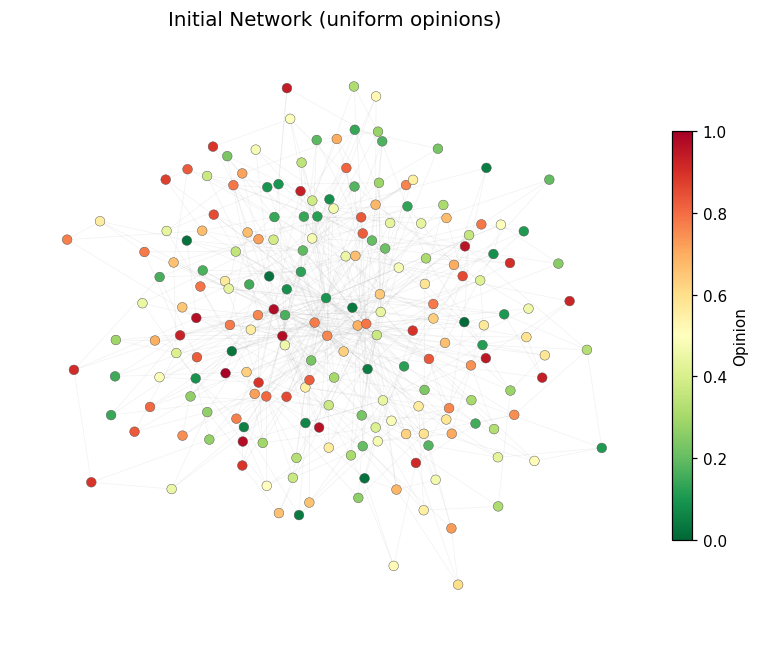

In [37]:
pos = plot_network_opinion(G, title="Initial Network (uniform opinions)", layout="spring")

---
## 2 · Model HK — only opinion convergence (without network changes)

Here we can see how HK works without modifying the structure of the network.
Only actualize opinions until system convergence

The key parameter is **ε (epsilon)**:  
- ε small → more clusters, high polarization 
- ε big → consensus

In [76]:
EPSILON = 0.05

result_hk_only = run_simulation(
    G,
    epsilon      = EPSILON,
    rewire       = False,   # without rewiring
    max_hk_steps = 6000,
    seed         = 42,
)

op_initial  = result_hk_only["snapshots"][0][1]
op_converged = result_hk_only["snapshots"][1][1]

print(f"ε = {EPSILON}")
print(f"Steps to convergence: {result_hk_only['phases'][0]['steps']}")
print(f"Opinion clusters: {n_clusters(op_converged)}")
print(f"Final variance: {opinion_variance(op_converged):.4f}")
print(f"Polarization Index: {polarization_index(op_converged):.4f}  (0=consenso, 1=máximo)")

ε = 0.05
Steps to convergence: 145
Opinion clusters: 113
Final variance: 0.0791
Polarization Index: 0.3162  (0=consenso, 1=máximo)


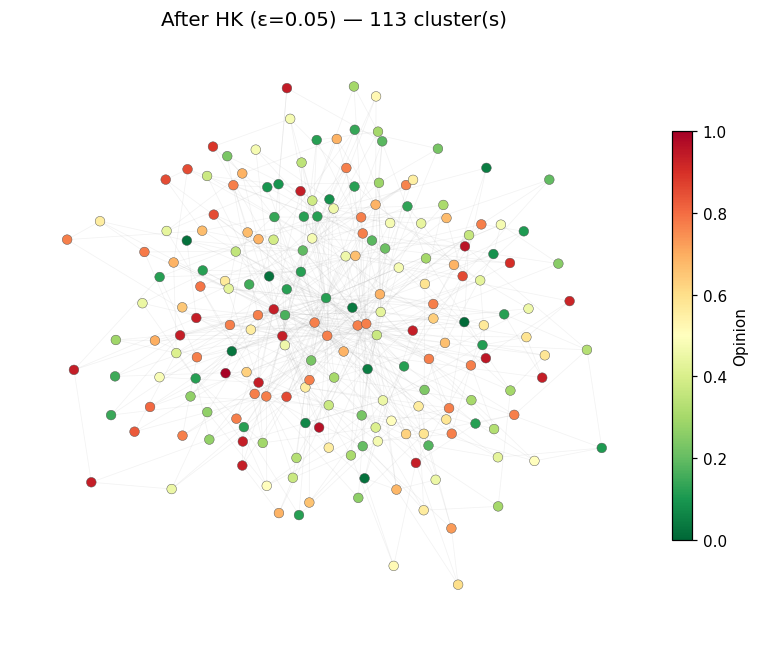

{0: array([-0.07019559, -0.01173766]),
 1: array([0.15755732, 0.02813591]),
 2: array([-0.16690756, -0.29152485]),
 3: array([ 0.07814451, -0.02263234]),
 4: array([-0.03068329,  0.08077093]),
 5: array([-0.21080387,  0.03824213]),
 6: array([-0.02678468, -0.06151019]),
 7: array([ 0.10764486, -0.01627619]),
 8: array([-0.11721013,  0.17959924]),
 9: array([0.03685603, 0.23825515]),
 10: array([ 0.14411294, -0.05898447]),
 11: array([-0.53332056, -0.05981065]),
 12: array([0.15472143, 0.09508647]),
 13: array([0.09564235, 0.3242878 ]),
 14: array([ 0.16522181, -0.30506469]),
 15: array([ 0.0920801 , -0.36169176]),
 16: array([-0.1020177 , -0.25611429]),
 17: array([-0.10156354, -0.39039264]),
 18: array([-0.47542859, -0.14237161]),
 19: array([-0.30450382, -0.19849636]),
 20: array([-0.26529641,  0.01634491]),
 21: array([-0.34162191,  0.25585663]),
 22: array([-0.1811671 , -0.06243962]),
 23: array([-0.26306565, -0.23796299]),
 24: array([-0.36184981, -0.02077054]),
 25: array([-0.110

In [77]:
plot_network_opinion(
    result_hk_only["G"],
    opinions = op_converged,
    title    = f"After HK (ε={EPSILON}) — {n_clusters(op_converged)} cluster(s)",
    pos      = pos,
)

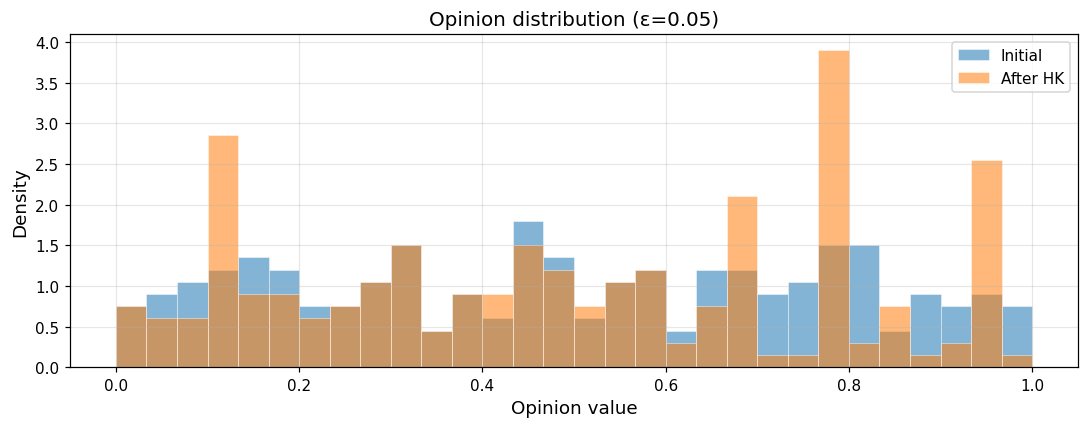

In [60]:
plot_opinion_histogram({
    "Initial"    : op_initial,
    "After HK"    : op_converged,
}, title=f"Opinion distribution (ε={EPSILON})")

### Evaluation of ε performance

We explore diffenrent epsilon values with the same network and we see how the variance change.

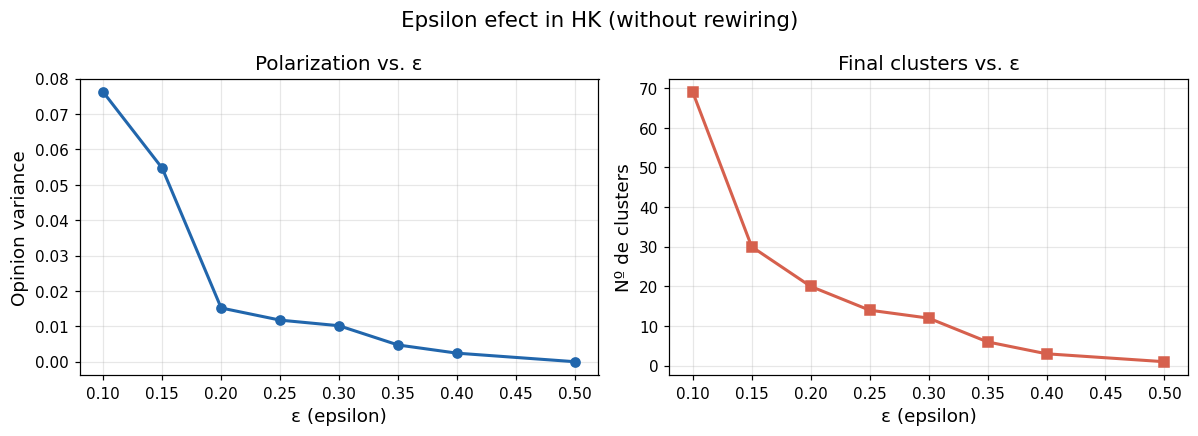

In [61]:
epsilons = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
variances = []
num_clusters = []

for eps in epsilons:
    r = run_simulation(G, epsilon=eps, rewire=False, seed=42)
    final_op = r["snapshots"][-1][1]
    variances.append(opinion_variance(final_op))
    num_clusters.append(n_clusters(final_op))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epsilons, variances, "o-", color="#2166ac", linewidth=2)
ax1.set_xlabel("ε (epsilon)", fontsize=12)
ax1.set_ylabel("Opinion variance", fontsize=12)
ax1.set_title("Polarization vs. ε", fontsize=13)
ax1.grid(True, alpha=0.3)

ax2.plot(epsilons, num_clusters, "s-", color="#d6604d", linewidth=2)
ax2.set_xlabel("ε (epsilon)", fontsize=12)
ax2.set_ylabel("Nº de clusters", fontsize=12)
ax2.set_title("Final clusters vs. ε", fontsize=13)
ax2.yaxis.get_major_locator().set_params(integer=True)
ax2.grid(True, alpha=0.3)

plt.suptitle("Epsilon efect in HK (without rewiring)", fontsize=14)
plt.tight_layout()
plt.show()

## 3 · HK + Homophilic Rewiring → Echo Chambers

Now we activate rewiring: in each round, edges between nodes with **distant opinions** are removed and replaced with edges between nodes holding **similar opinions**. The network reconfigures itself to isolate groups. Humanity reinventing tribalism with extra steps. Remarkable species.

Rewiring parameters:

| Parameter | Effect |
|-----------|--------|
| `p_rewire` | Probability of cutting each discordant edge per round. Higher values → faster rewiring. |
| `rewire_steps` | Number of rewiring rounds. Higher values → stronger fragmentation. |
| `hk_steps_per_rewire` | Number of HK steps between rewiring rounds. |

In [62]:
result = run_simulation(
    G,
    epsilon             = 0.05,
    rewire              = True,
    p_rewire            = 0.05,    
    rewire_steps        = 300,
    hk_steps_per_rewire = 5,
    seed                = 42,
)

op_final = result["snapshots"][-1][1]

print(f"Clusters final opinions: {n_clusters(op_final)}")
print(f"Final variance: {opinion_variance(op_final):.4f}")
print(f"Polarization Index: {polarization_index(op_final):.4f}")

mod    = result["metrics"].get("modularity",    [float("nan")])[-1]
n_comm = result["metrics"].get("n_communities", [float("nan")])[-1]
if not np.isnan(mod):
    print(f"Final Modularity: {mod:.4f}")
    print(f"Detected Communities: {int(n_comm)}")
else:
    print("Modularity: N/A  (install python-louvain to activate it)")


Clusters final opinions: 15
Final variance: 0.0788
Polarization Index: 0.3153
Modularity: N/A  (install python-louvain to activate it)


### Snapshots: evolución de la red en el tiempo

Tres momentos: estado inicial → tras HK puro → tras rewiring.

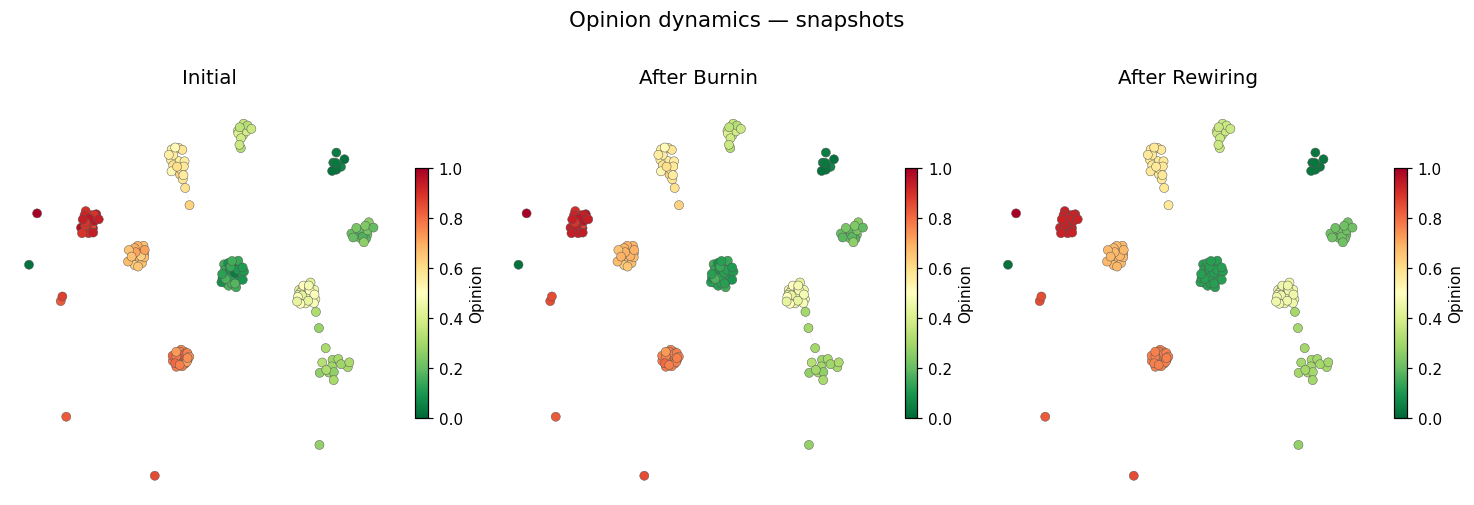

In [63]:
plot_snapshots(
    result["G"],
    result["snapshots"],
    layout   = "spring",
    color_by = "opinion",
)

### Communities Detected by Louvain — After Rewiring

Each color represents a distinct community detected automatically.  
The more isolated communities there are, the stronger the fragmentation.

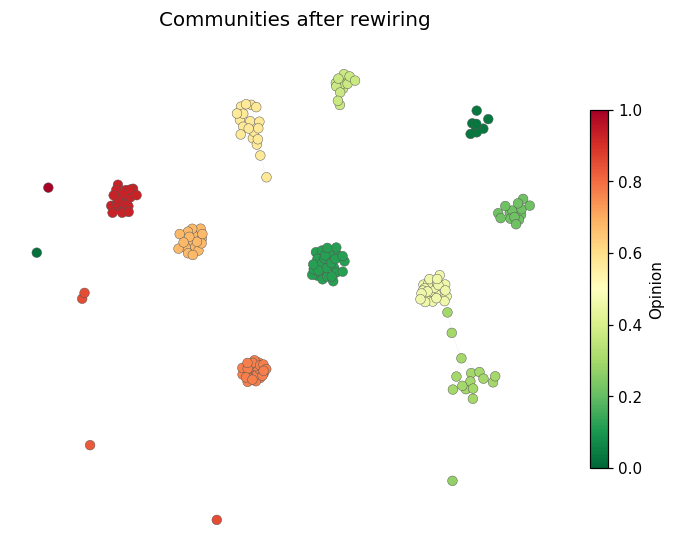

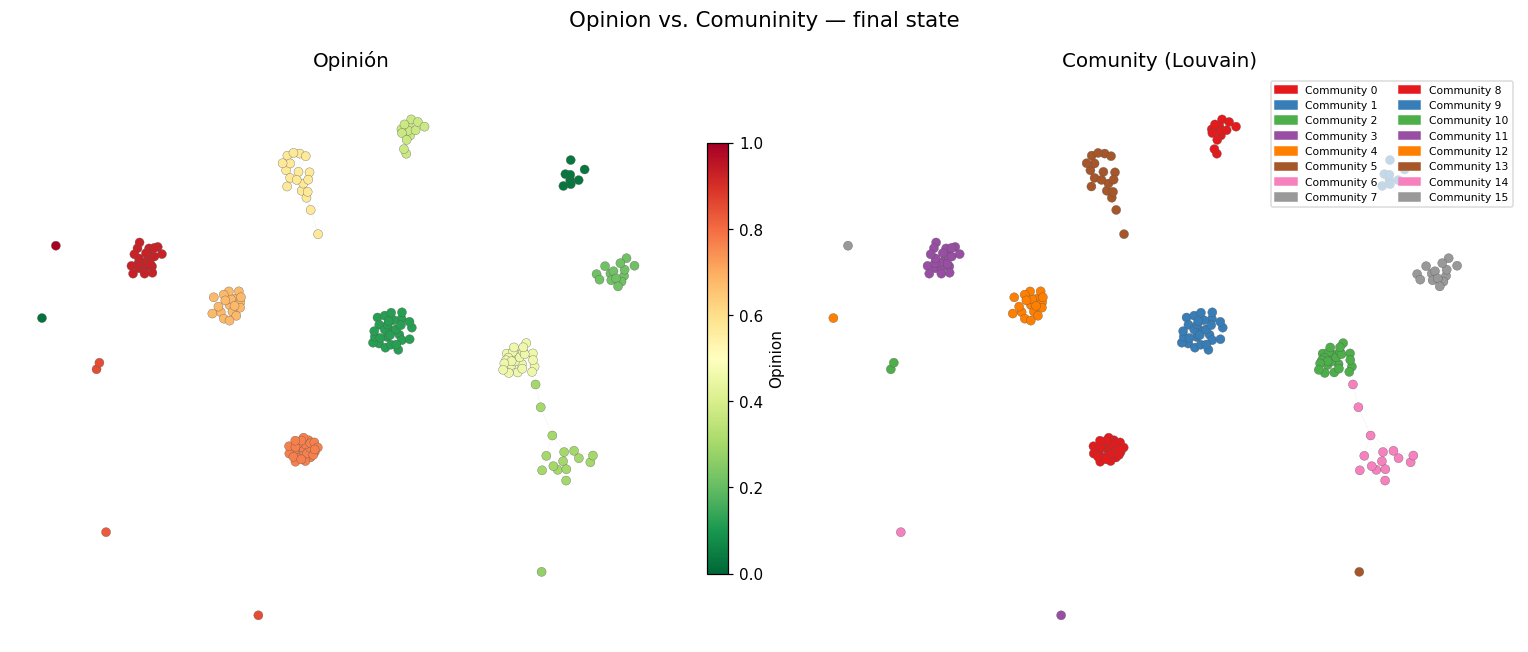

In [64]:
plot_network_community(
    result["G"],
    title  = "Communities after rewiring",
    layout = "spring",
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
import copy, networkx as nx
G_final = result["G"]
op_final_arr = result["snapshots"][-1][1]

from visualization import _get_layout, _opinion_colors, _community_colors
import matplotlib.cm as cm, matplotlib.colors as mcolors, matplotlib.patches as mpatches

from networkx.algorithms.community import greedy_modularity_communities as _nx_comm
from networkx.algorithms.community import modularity as _nx_mod

G_final = result["G"]
op_final_arr = result["snapshots"][-1][1]

communities = list(_nx_comm(G_final))
partition = {}
for cid, comm in enumerate(communities):
    for node in comm:
        partition[node] = cid
nx.set_node_attributes(G_final, partition, "community")


pos_final = _get_layout(G_final, None, "spring")

colors_op = _opinion_colors(op_final_arr)
nx.draw_networkx_edges(G_final, pos_final, ax=ax1, alpha=0.12, edge_color="#aaa", width=0.5)
nx.draw_networkx_nodes(G_final, pos_final, ax=ax1, node_color=colors_op, node_size=35, linewidths=0.2, edgecolors="#555")
sm = cm.ScalarMappable(norm=mcolors.Normalize(0,1), cmap="RdYlGn_r")
plt.colorbar(sm, ax=ax1, fraction=0.03, pad=0.02).set_label("Opinion")
ax1.set_title("Opinión", fontsize=13); ax1.axis("off")

# Panel derecho — comunidad
colors_comm, color_map = _community_colors(G_final)
nx.draw_networkx_edges(G_final, pos_final, ax=ax2, alpha=0.12, edge_color="#aaa", width=0.5)
nx.draw_networkx_nodes(G_final, pos_final, ax=ax2, node_color=colors_comm, node_size=35, linewidths=0.2, edgecolors="#555")
patches = [mpatches.Patch(color=c, label=f"Community {k}") for k, c in color_map.items()]
ax2.legend(handles=patches, fontsize=7, loc="upper right", ncol=2, framealpha=0.7)
ax2.set_title("Comunity (Louvain)", fontsize=13); ax2.axis("off")

plt.suptitle("Opinion vs. Comuninity — final state", fontsize=14)
plt.tight_layout()
plt.show()

# Resumen numérico
mod    = result["metrics"].get("modularity",    [float("nan")])[-1]
n_comm = result["metrics"].get("n_communities", [float("nan")])[-1]
if not np.isnan(mod):
    print(f"Final Modularity:      {mod:.4f}")
    print(f"Detected Communities: {int(n_comm)}")


### Metrics through simulation

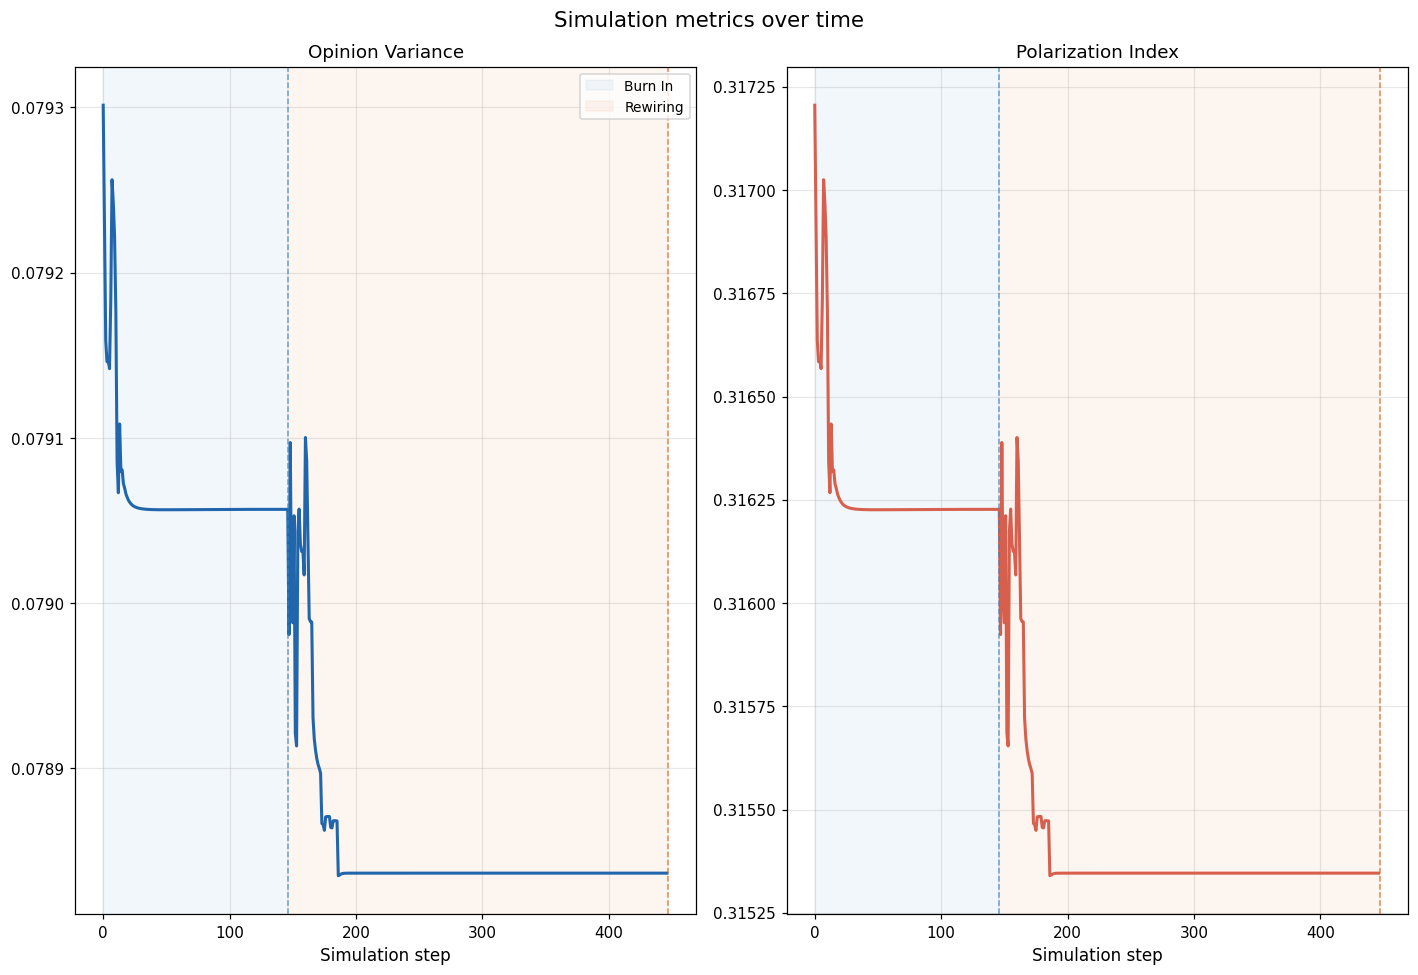

In [65]:
plot_metrics(result)

### Histogram before and after rewiring

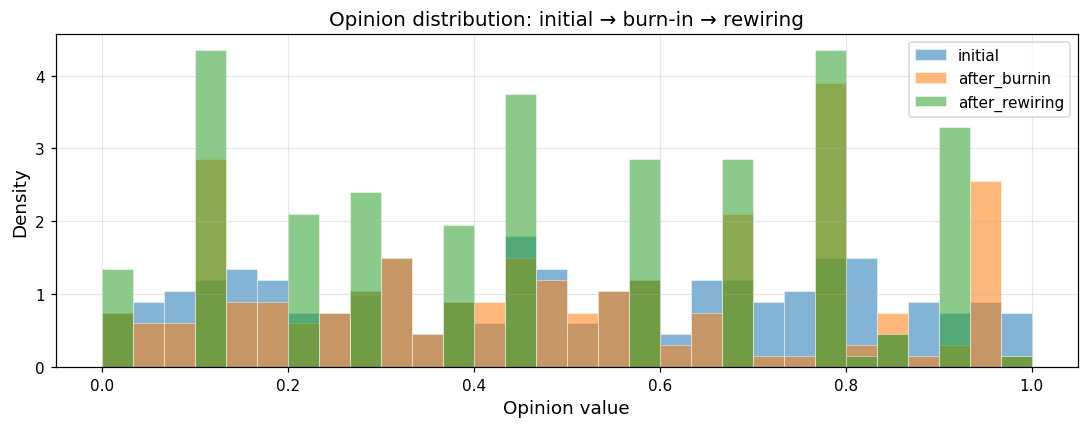

In [66]:
plot_opinion_histogram({
    label: op for label, op in result["snapshots"]
}, title="Opinion distribution: initial → burn-in → rewiring")

---
## 4 · Network Model Comparison

Does topology matter? We apply the same experiment to ER, BA, and WS networks and compare the final polarization.

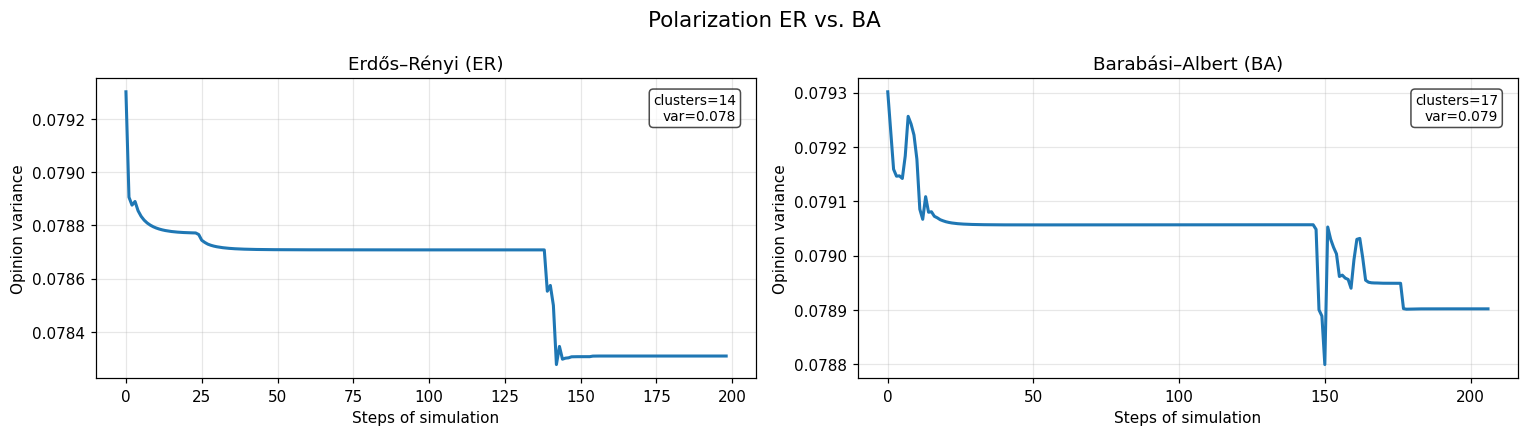

In [67]:
networks = {
    "Erdős–Rényi (ER)": make_network("ER", n=200, p=0.04, opinion="uniform", seed=42),
    "Barabási–Albert (BA)": make_network("BA", n=200, m=3, opinion="uniform", seed=42),
}

SIM_PARAMS = dict(epsilon=0.05, rewire=True, p_rewire=0.08,
                  rewire_steps=60, hk_steps_per_rewire=5, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, Gnet) in zip(axes, networks.items()):
    r = run_simulation(Gnet, **SIM_PARAMS)
    var_series = r["metrics"]["opinion_variance"]
    ax.plot(var_series, linewidth=2)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Steps of simulation")
    ax.set_ylabel("Opinion variance")
    ax.grid(True, alpha=0.3)
    final_op = r["snapshots"][-1][1]
    ax.text(0.97, 0.95,
            f"clusters={n_clusters(final_op)}\nvar={opinion_variance(final_op):.3f}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

plt.suptitle("Polarization ER vs. BA", fontsize=14)
plt.tight_layout()
plt.show()

---
## 5 · Sandbox — experimenta libremente

Usa esta celda para probar combinaciones de parámetros.

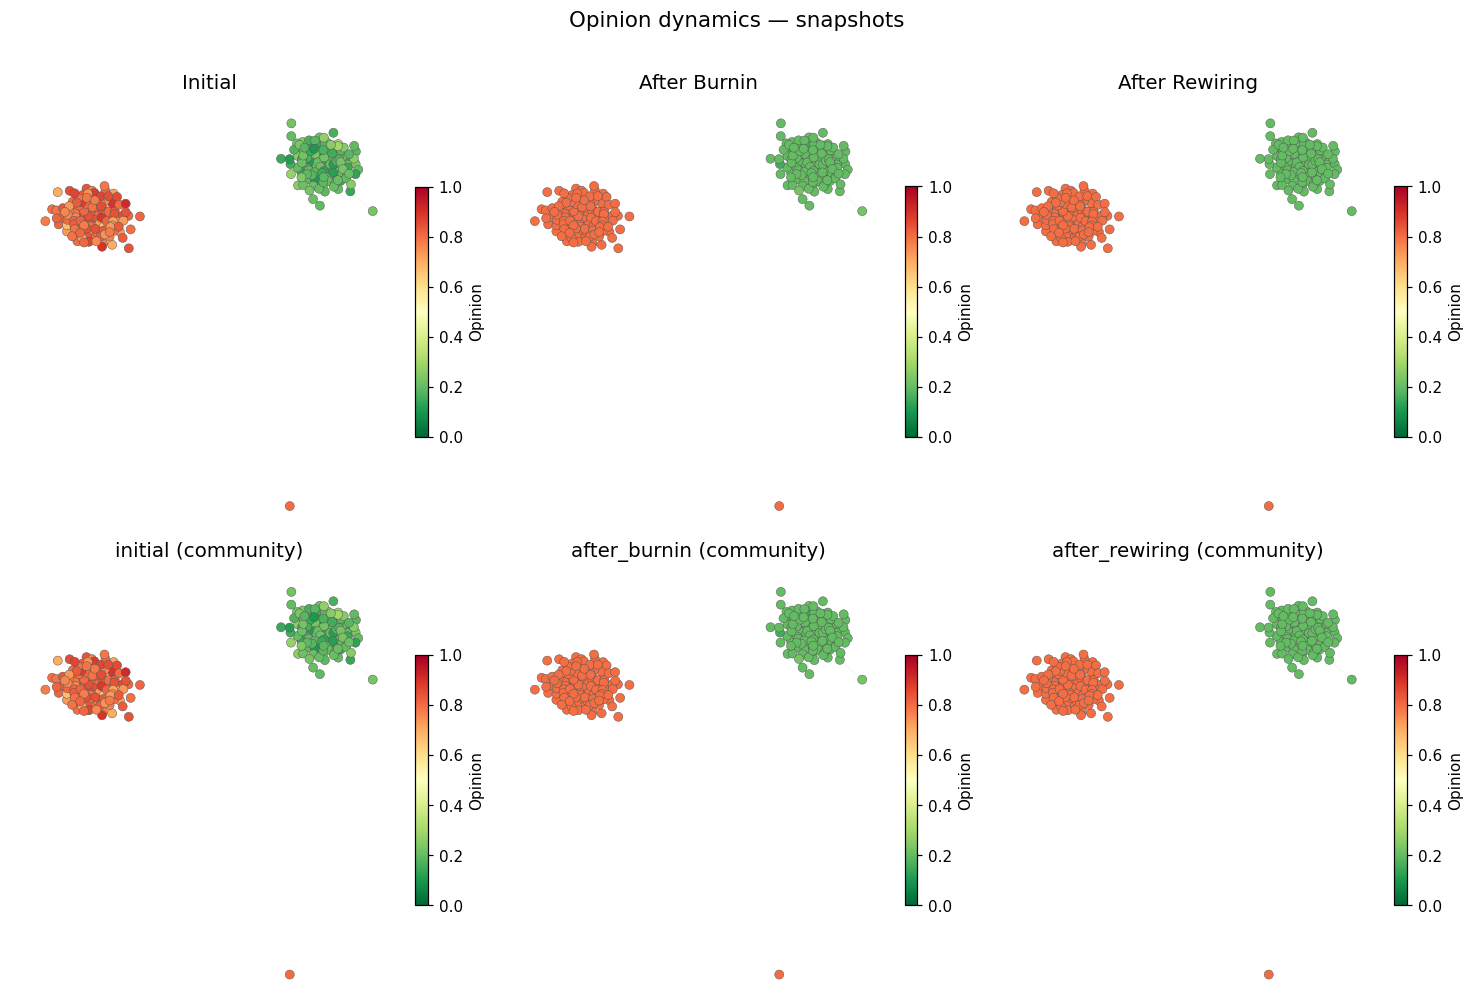

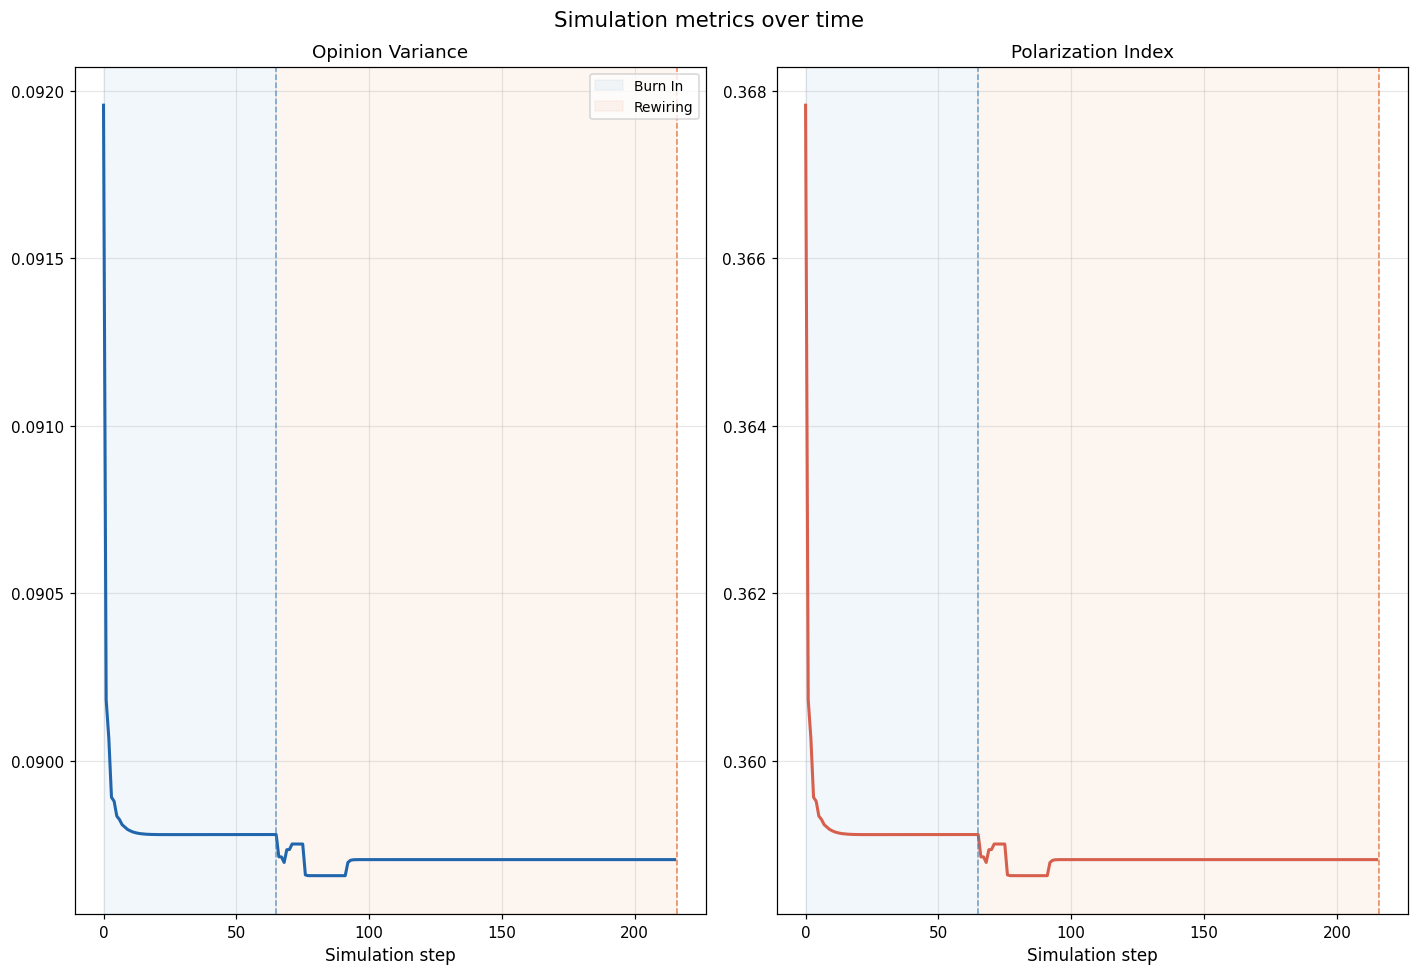

In [68]:
# --- Cambia lo que quieras aquí ---
G_exp = make_network(
    model   = "BA",       # "ER" | "BA" | "WS"
    n       = 250,
    m       = 4,
    opinion = "bimodal",  # "uniform" | "bimodal" | "clustered"
    seed    = 7,
)

r_exp = run_simulation(
    G_exp,
    epsilon             = 0.20,
    rewire              = True,
    p_rewire            = 0.10,
    rewire_steps        = 150,
    hk_steps_per_rewire = 5,
    seed                = 7,
)

plot_snapshots(r_exp["G"], r_exp["snapshots"], color_by="both")
plot_metrics(r_exp)

---
## 6 · Repair Phase — Mediator Strategy

After rewiring the network is completely fragmented: communities have zero connections between them.
We inject **mediator nodes** (opinion fixed at 0.5) that bridge every community hub,
and let a sigma-weighted HK pull opinions toward the centre.

| Parameter | Effect |
|-----------|--------|
| `n_mediators` | Bridge nodes added (once, at start of repair) |
| `sigma_mode` | `"uniform"` = all nodes equally open · `"inv_degree"` = hubs more rigid |
| `sigma_value` | Convincibility level for uniform mode (0 = frozen, 1 = standard HK) |
| `repair_steps` | Number of repair rounds |
| `hk_steps_per_repair` | HK steps between rounds |

In [69]:
import copy
import networkx as nx
from repair import MediatorStrategy, run_repair_phase

# --- 1. Polarized graph (same params as Section 3) ---
G_pol = make_network('BA', n=200, m=3, opinion='uniform', seed=42)
result_pol = run_simulation(
    G_pol,
    epsilon             = 0.05,
    rewire              = True,
    p_rewire            = 0.05,
    rewire_steps        = 300,
    hk_steps_per_rewire = 5,
    seed                = 42,
)

op_before = result_pol['snapshots'][-1][1]
n_comp    = nx.number_connected_components(result_pol['G'])

print('=== Before repair (input to repair phase) ===')
print(f'  Opinion clusters : {n_clusters(op_before)}')
print(f'  Variance         : {opinion_variance(op_before):.4f}')
print(f'  Polarization idx : {polarization_index(op_before):.4f}')
print(f'  Connected comps  : {n_comp}  (0 bridges between communities if >1)')

=== Before repair (input to repair phase) ===
  Opinion clusters : 15
  Variance         : 0.0788
  Polarization idx : 0.3153
  Connected comps  : 16  (0 bridges between communities if >1)


In [70]:
# --- 2. Run repair phase ---
G_repair = copy.deepcopy(result_pol['G'])
n_normal  = G_repair.number_of_nodes()   # save BEFORE mediators are added

strategy = MediatorStrategy(
    n_mediators = 5,
    sigma_mode  = 'inv_degree',   # try also 'inv_degree'
    sigma_value = 0.7,
)

phase_repair = run_repair_phase(
    G            = G_repair,
    strategy     = strategy,
    epsilon      = 0.05,
    repair_steps = 2000,
    hk_steps_per_repair = 5,
    seed         = 0,
)

# Mediators are appended at the END of G.nodes() — slice to get normal nodes only
# history[0] is pre-mediator (size n_normal); history[1:] are post (size n_normal + 20)
repair_ops = [h[:n_normal] for h in phase_repair['history']]
op_after   = repair_ops[-1]

print('=== After repair ===')
print(f'  Opinion clusters : {n_clusters(op_after)}')
print(f'  Variance         : {opinion_variance(op_after):.4f}')
print(f'  Polarization idx : {polarization_index(op_after):.4f}')
print(f'  Connected comps  : {nx.number_connected_components(G_repair)}')

=== After repair ===
  Opinion clusters : 9
  Variance         : 0.0394
  Polarization idx : 0.1574
  Connected comps  : 1


/var/folders/tf/rh2grj_j239fbyx5vlzz54r40000gn/T/ipykernel_29205/2421838462.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


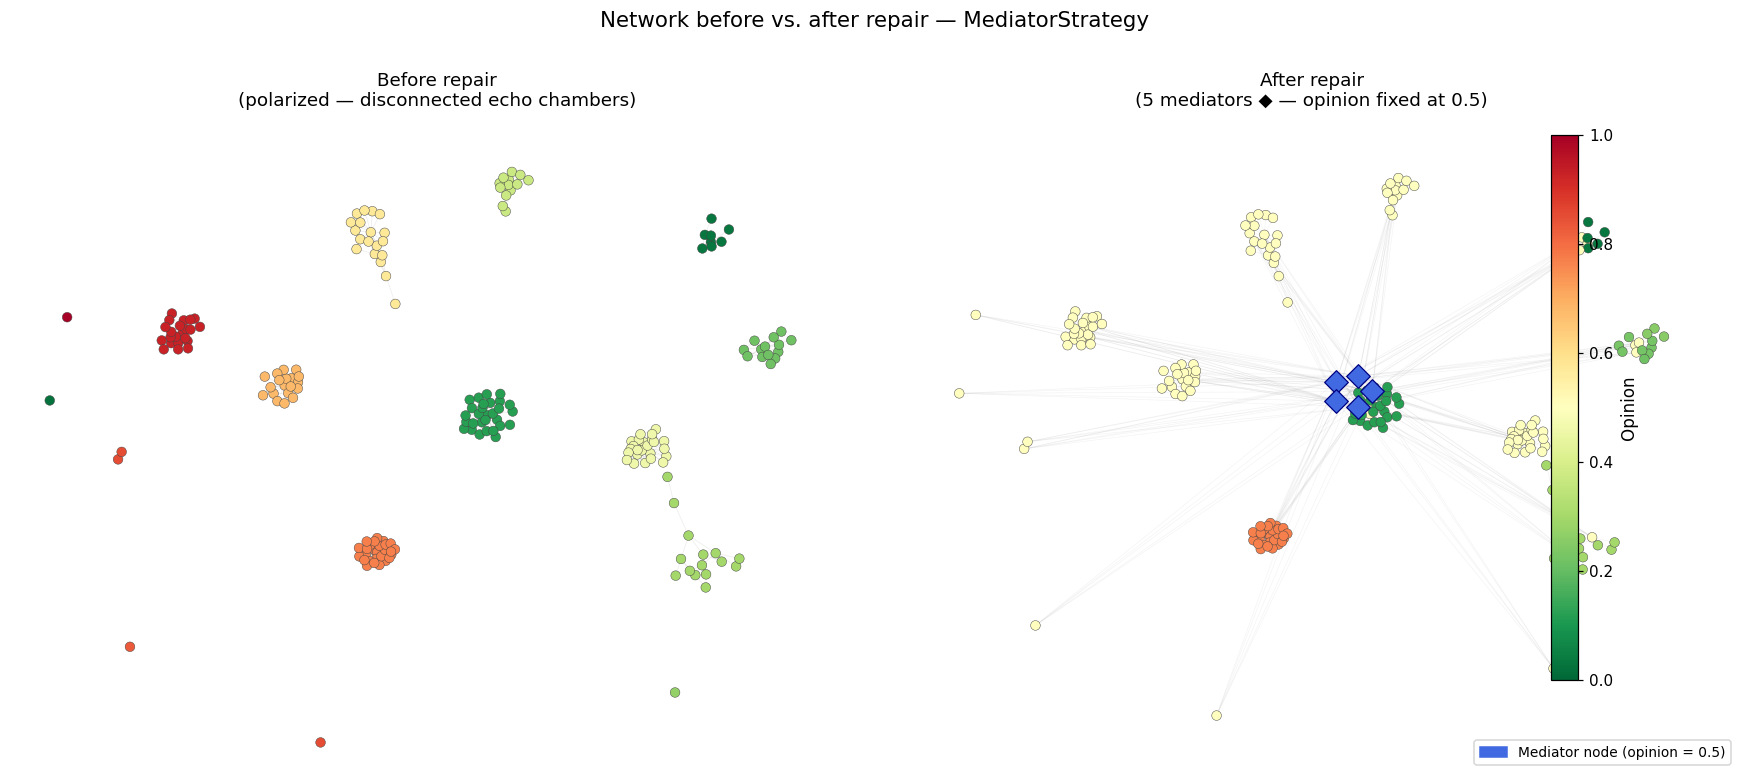

In [71]:
# --- Network: polarized vs. repaired ---
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from visualization import _get_layout, _opinion_colors

fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(16, 7))

# ---- LEFT: polarized graph ----
G_before  = result_pol['G']
pos_before = _get_layout(G_before, None, 'spring')
colors_before = _opinion_colors(op_before)

nx.draw_networkx_edges(G_before, pos_before, ax=ax_before,
                        alpha=0.15, edge_color='#888', width=0.5)
nx.draw_networkx_nodes(G_before, pos_before, ax=ax_before,
                        node_color=colors_before, node_size=40,
                        linewidths=0.3, edgecolors='#444')
ax_before.set_title('Before repair\n(polarized — disconnected echo chambers)',
                     fontsize=12, pad=10)
ax_before.axis('off')

# ---- RIGHT: repaired graph ----
normal_nodes   = [n for n in G_repair.nodes()
                   if not G_repair.nodes[n].get('is_mediator', False)]
mediator_nodes = [n for n in G_repair.nodes()
                   if G_repair.nodes[n].get('is_mediator', False)]

# Reuse positions for original nodes; place mediators at center
pos_after = {n: pos_before[n] for n in normal_nodes}
cx, cy = 0.0, 0.0   # mediators clustered at centroid
for k, m in enumerate(mediator_nodes):
    angle = 2 * np.pi * k / len(mediator_nodes)
    pos_after[m] = (cx + 0.05 * np.cos(angle), cy + 0.05 * np.sin(angle))

colors_after_nodes = _opinion_colors(op_after)

nx.draw_networkx_edges(G_repair, pos_after, ax=ax_after,
                        alpha=0.10, edge_color='#888', width=0.4)
nx.draw_networkx_nodes(G_repair, pos_after,
                        nodelist=normal_nodes, ax=ax_after,
                        node_color=colors_after_nodes, node_size=40,
                        linewidths=0.3, edgecolors='#444')
nx.draw_networkx_nodes(G_repair, pos_after,
                        nodelist=mediator_nodes, ax=ax_after,
                        node_color='royalblue', node_size=120,
                        node_shape='D', linewidths=0.8, edgecolors='navy')
ax_after.set_title(f'After repair\n({len(mediator_nodes)} mediators ◆ — opinion fixed at 0.5)',
                    fontsize=12, pad=10)
ax_after.axis('off')

# Shared colorbar
sm = cm.ScalarMappable(norm=mcolors.Normalize(0, 1), cmap='RdYlGn_r')
cbar = plt.colorbar(sm, ax=[ax_before, ax_after], fraction=0.02, pad=0.02)
cbar.set_label('Opinion', fontsize=11)

# Legend for mediators
med_patch = mpatches.Patch(color='royalblue', label='Mediator node (opinion = 0.5)')
ax_after.legend(handles=[med_patch], loc='lower right', fontsize=9, framealpha=0.8)

plt.suptitle('Network before vs. after repair — MediatorStrategy', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

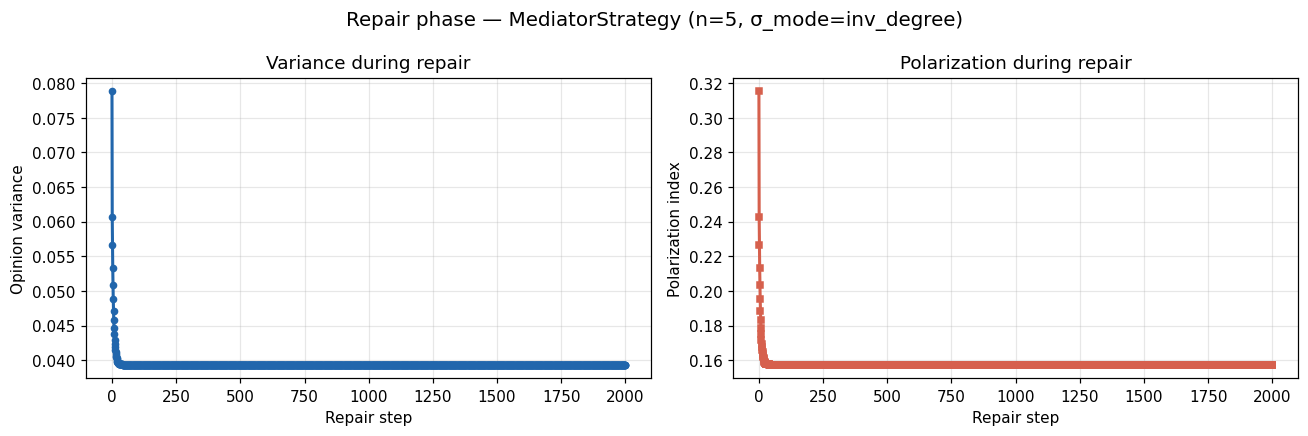

In [72]:
# --- 3. Opinion evolution during repair ---
repair_var  = [opinion_variance(op)    for op in repair_ops]
repair_pol  = [polarization_index(op)  for op in repair_ops]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(repair_var, 'o-', color='#2166ac', linewidth=2, markersize=4)
ax1.set_xlabel('Repair step'); ax1.set_ylabel('Opinion variance')
ax1.set_title('Variance during repair'); ax1.grid(True, alpha=0.3)

ax2.plot(repair_pol, 's-', color='#d6604d', linewidth=2, markersize=4)
ax2.set_xlabel('Repair step'); ax2.set_ylabel('Polarization index')
ax2.set_title('Polarization during repair'); ax2.grid(True, alpha=0.3)

plt.suptitle(f'Repair phase — MediatorStrategy (n={strategy.n_mediators}, σ_mode={strategy.sigma_mode})', fontsize=13)
plt.tight_layout()
plt.show()

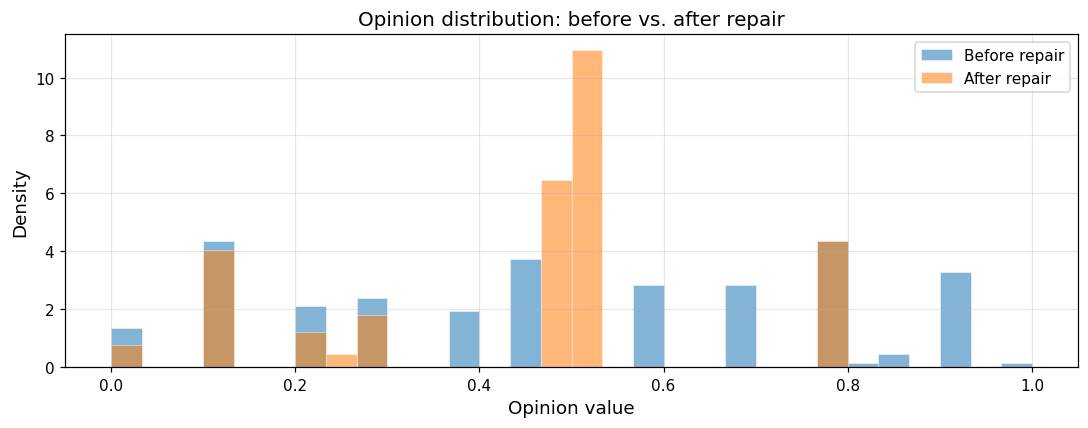

In [73]:
# --- 4. Opinion histogram: before vs. after ---
plot_opinion_histogram({
    'Before repair' : op_before,
    'After repair'  : op_after,
}, title='Opinion distribution: before vs. after repair')